# XGBoost Regression for CPU Usage Forecasting

This notebook demonstrates how to use XGBoost for time series regression using engineered features. We will:
- Load and inspect the feature-engineered dataset
- Prepare features and target
- Train and validate an XGBoost model
- Evaluate performance
- Save the trained model

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect Data
Load the train, validation, and test splits. Display the first few rows and basic statistics.

In [6]:
# Load the feature-engineered dataset splits using absolute paths and check shapes
import os
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'splits'))
train_path = os.path.join(base_dir, 'train.csv')
val_path = os.path.join(base_dir, 'val.csv')
test_path = os.path.join(base_dir, 'test.csv')

train = pd.read_csv(train_path, parse_dates=['date'])
val = pd.read_csv(val_path, parse_dates=['date'])
test = pd.read_csv(test_path, parse_dates=['date'])

print('Train shape:', train.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)

if train.empty or val.empty or test.empty:
    raise ValueError('One or more splits are empty! Check your file paths and data.')

display(train.head())
display(train.describe())

Train shape: (708, 33)
Validation shape: (180, 33)
Test shape: (192, 33)


,date,region,resource_type,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,holiday,day_of_week,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
0,2023-01-01,eastus,Container,70,621,414,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707071,0.311278
1,2023-01-01,northeurope,Container,82,959,221,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828283,0.485324
2,2023-01-01,northeurope,Storage,51,1715,476,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.520408,0.873218
3,2023-01-01,northeurope,VM,73,1937,493,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.737374,0.971414
4,2023-01-01,eastus,Storage,92,1595,388,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.929293,0.800703


,date,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,day_of_week,month,quarter,is_weekend,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
count,708,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.0,708.000000,...,684.00000,684.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,708.000000,708.000000
mean,2023-01-30 00:00:00,74.936441,1251.706215,351.134181,98.535085,0.995763,2.966102,1.474576,1.0,0.288136,...,1621.52924,858.918129,75.113657,93.484277,55.844340,1243.311545,1799.199686,651.823899,0.757576,0.631853
min,2023-01-01 00:00:00,50.000000,500.000000,200.000000,73.800000,0.800000,0.000000,1.000000,1.0,0.000000,...,553.00000,500.000000,58.285714,69.000000,50.000000,688.142857,1023.000000,500.000000,0.505051,0.251254
25%,2023-01-15 00:00:00,62.000000,862.000000,280.750000,93.980000,0.940000,1.000000,1.000000,1.0,0.000000,...,1455.50000,590.000000,71.142857,90.750000,51.000000,1124.500000,1719.000000,533.000000,0.626263,0.437177
50%,2023-01-30 00:00:00,75.000000,1291.500000,350.500000,99.280000,0.990000,3.000000,1.000000,1.0,0.000000,...,1687.50000,790.000000,75.285714,96.000000,54.000000,1245.928571,1832.000000,589.000000,0.757576,0.652334
75%,2023-02-14 00:00:00,87.000000,1622.250000,426.000000,103.310000,1.050000,5.000000,2.000000,1.0,1.000000,...,1850.00000,1058.500000,79.321429,97.000000,59.000000,1372.428571,1934.000000,736.000000,0.887755,0.820793
max,2023-02-28 00:00:00,99.000000,1995.000000,499.000000,118.860000,1.250000,6.000000,2.000000,1.0,1.000000,...,1995.00000,1823.000000,90.142857,99.000000,75.000000,1710.142857,1995.000000,1543.000000,1.000000,1.000000
std,NaN,14.600098,440.175571,86.943854,8.569861,0.098363,2.043095,0.499706,0.0,0.453215,...,290.95893,311.090881,5.714503,5.375776,5.576891,175.254693,164.854246,159.984833,0.147612,0.222165


## Prepare Features and Target
Select features (X) and target (y). Encode categorical variables and scale features if needed.

In [12]:
# Drop columns not used as features
ignore_cols = ['date', 'region', 'resource_type', 'usage_cpu', 'usage_storage']
# Remove any columns that contain the target or its direct lags/rolling stats from features
leakage_cols = [col for col in train.columns if ('usage_cpu' in col or 'cpu' in col) and col not in ['usage_cpu']]
feature_cols = [col for col in train.columns if col not in ignore_cols + leakage_cols]

# Use all numeric and engineered features (without leakage)
X_train = train[feature_cols]
X_val = val[feature_cols]
X_test = test[feature_cols]
y_train = train['usage_cpu']
y_val = val['usage_cpu']
y_test = test['usage_cpu']

# Optionally scale features (XGBoost is robust, but scaling can help)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Feature columns (no leakage):', feature_cols)

# Check for high correlation between features and target
corrs = train[feature_cols + ['usage_cpu']].corr()['usage_cpu'].abs().sort_values(ascending=False)
print('Top feature correlations with target:')
print(corrs[1:6])

Feature columns (no leakage): ['users_active', 'econ_index', 'cloud_market_demand', 'holiday', 'day_of_week', 'month', 'quarter', 'is_weekend', 'storage_usage_lag_1', 'storage_usage_lag_3', 'storage_usage_lag_7', 'storage_usage_rollmean_3', 'storage_usage_rollmax_3', 'storage_usage_rollmin_3', 'storage_usage_rollmean_7', 'storage_usage_rollmax_7', 'storage_usage_rollmin_7', 'storage_efficiency']
Top feature correlations with target:
storage_usage_rollmin_7     0.117143
storage_usage_rollmean_7    0.097105
econ_index                  0.079213
storage_usage_rollmin_3     0.056958
storage_usage_lag_1         0.056619
Name: usage_cpu, dtype: float64


## Train and Validate XGBoost Model
Train the XGBoost regressor on the training set and evaluate on the validation set.

In [13]:
# Train XGBoost regressor
print('X_train shape:', X_train_scaled.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val_scaled.shape)
print('y_val shape:', y_val.shape)

if X_train_scaled.shape[0] == 0 or X_val_scaled.shape[0] == 0:
    raise ValueError('Training or validation data is empty! Check your splits and feature selection.')

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], early_stopping_rounds=10, verbose=True)

# Predict on validation set
val_pred = xgb.predict(X_val_scaled)

# Evaluate
mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print(f"Validation MAE: {mae:.2f}")
print(f"Validation RMSE: {rmse:.2f}")

X_train shape: (708, 18)
y_train shape: (708,)
X_val shape: (180, 18)
y_val shape: (180,)
[0]	validation_0-rmse:13.84632
[1]	validation_0-rmse:13.87321
[1]	validation_0-rmse:13.87321
[2]	validation_0-rmse:13.90294
[3]	validation_0-rmse:13.96231
[4]	validation_0-rmse:13.96276
[5]	validation_0-rmse:13.97272
[6]	validation_0-rmse:13.99757
[2]	validation_0-rmse:13.90294
[3]	validation_0-rmse:13.96231
[4]	validation_0-rmse:13.96276
[5]	validation_0-rmse:13.97272
[6]	validation_0-rmse:13.99757
[7]	validation_0-rmse:13.97313
[8]	validation_0-rmse:14.00112
[9]	validation_0-rmse:13.99784
[10]	validation_0-rmse:13.99748
Validation MAE: 12.21
Validation RMSE: 13.85
[7]	validation_0-rmse:13.97313
[8]	validation_0-rmse:14.00112
[9]	validation_0-rmse:13.99784
[10]	validation_0-rmse:13.99748
Validation MAE: 12.21
Validation RMSE: 13.85


## Evaluate on Test Set
Predict on the test set and report final performance metrics.

Test MAE: 13.05
Test RMSE: 15.10


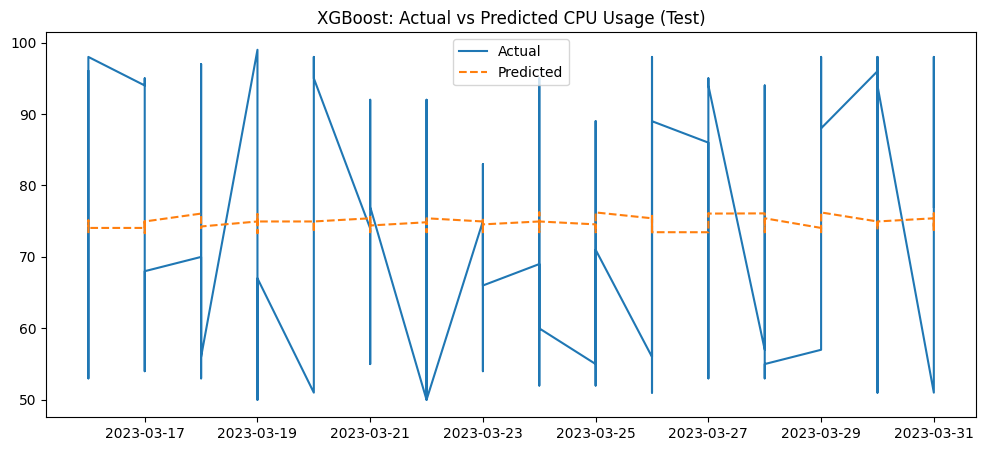

In [14]:
# Predict on test set
pred_test = xgb.predict(X_test_scaled)
mae_test = mean_absolute_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], pred_test, label='Predicted', linestyle='--')
plt.title('XGBoost: Actual vs Predicted CPU Usage (Test)')
plt.legend()
plt.show()

## Save the Trained Model
Save the trained XGBoost model and scaler for later use.

In [17]:
# Save model and scaler
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb, '../models/xgboost_model.pkl')
joblib.dump(scaler, '../models/xgb_scaler.pkl')
print('Model and scaler saved to models/.')

Model and scaler saved to models/.


## Additional Evaluation Metrics: MAPE and Forecast Bias
Calculate MAPE (Mean Absolute Percentage Error) and forecast bias for the XGBoost model on the test set.

In [16]:
# MAPE
mape = np.mean(np.abs((y_test - pred_test) / y_test)) * 100
print(f"Test MAPE: {mape:.2f}%")

# Forecast Bias
bias = np.mean(pred_test - y_test)
print(f"Forecast Bias: {bias:.2f}")

Test MAPE: 18.79%
Forecast Bias: 0.57
